# Pearson Correlation Analysis: Network Indicators vs GDP
## Chinese Migration Network (1980-2016)

This notebook calculates Pearson correlation coefficients between network indicators and GDP across:
- **Overall Network**: All migration communities combined
- **Individual Migration Communities**: C1, C2, C3, ... (detected via Louvain algorithm)

## Network Indicators Analyzed

**Core Hub Metrics:**
- **B** (gatewayness): Z-score of outside-module degree
- **Z** (provincialness): Z-score of inside-module degree
- **P** (connectorness): Participation coefficient

**Centrality Metrics:**
- **K** (degree): Node degree (weighted)
- **BC** (betweenness): Betweenness centrality
- **CC** (clustering): Clustering coefficient

**Rich-Club & Connectivity Metrics:**
- **AND** (average_neighbor_degree): Average degree of neighbors (rich-club proxy)
- **CN** (core_number): K-core decomposition value
- **LHC** (local_hub_connectivity): Local hub connectivity ratio

## Input Files
- `network_metrics_nodes_updated.csv` - Node-level migration network metrics with B, Z, P, AND, CN, LHC calculated (random seed = 8)
- `econ_data_en.csv` - Economic data including regional GDP

## Output Files
- `correlation_network_gdp_yearly_by_community.csv` - Year-by-year correlations (long format)
- `correlation_network_gdp_formatted_all_years.csv` - Formatted tables with significance markers
- `correlation_heatmap_year_YYYY.png` - Heatmap visualizations for specific years
- `correlation_temporal_evolution_overall.png` - Temporal evolution plot

## 1. Setup and Imports

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Pre-calculated Data

In [12]:
# Load network metrics (with B, Z, P calculated using random seed = 8)
print("Loading network metrics...")
network_metrics = pd.read_csv('network_metrics_nodes_updated.csv')
print(f"✓ Network metrics: {network_metrics.shape}")
print(f"  Columns: {network_metrics.columns.tolist()}")

# Load economic data
print("\nLoading economic data...")
econ_data = pd.read_csv('econ_data_en.csv')
print(f"✓ Economic data: {econ_data.shape}")
print(f"  Columns (first 10): {econ_data.columns.tolist()[:10]}...")

# Check for GDP column
if 'gdp_regional_10k' in econ_data.columns:
    print("✓ Found GDP column: gdp_regional_10k")
else:
    print("⚠ WARNING: gdp_regional_10k not found")
    print(f"Available columns: {econ_data.columns.tolist()}")

Loading network metrics...
✓ Network metrics: (71690, 26)
  Columns: ['granularity', 'years', 'year', 'node_id', 'degree', 'degree_unweighted', 'clustering', 'local_efficiency', 'betweenness', 'closeness', 'eigenvector', 'pagerank', 'radiality', 'average_neighbor_degree', 'core_number', 'local_hub_connectivity', 'community', 'gatewayness', 'provincialness', 'connectorness', 'rich_club_coefficient', 'hub_type', 'is_gateway', 'is_provincial', 'is_connector', 'in_lcc']

Loading economic data...
✓ Economic data: (64992, 81)
  Columns (first 10): ['Unnamed: 0', 'year', 'province', 'city', 'district', 'admin_code', 'land_area_sqkm', 'townships_towns_total', 'townships_count', 'towns_count']...
✓ Found GDP column: gdp_regional_10k


## 3. Data Preparation and Merging

In [13]:
print("Preparing data for merging...\n")

# Filter to county level only (most granular)
df_county = network_metrics[network_metrics['granularity'] == 'county'].copy()
print(f"County-level network metrics: {len(df_county):,} rows")

# Remove 'all' years and ensure year is numeric
df_county = df_county[df_county['years'] != 'all'].copy()
df_county['year'] = df_county['year'].astype(float)
print(f"After removing 'all' years: {len(df_county):,} rows")

# Merge network metrics with economic data
print("\nMerging datasets...")
merged_data = df_county.merge(
    econ_data,
    left_on=['year', 'node_id'],
    right_on=['year', 'admin_code'],
    how='inner'
)

print(f"\n✓ Merged data: {merged_data.shape}")
print(f"  Year range: {merged_data['year'].min():.0f} - {merged_data['year'].max():.0f}")
print(f"  Unique years: {len(merged_data['year'].unique())} years")
print(f"  Unique communities: {len(merged_data['community'].unique())} communities")

# Check GDP availability
gdp_available = merged_data['gdp_regional_10k'].notna().sum()
print(f"\n  GDP data available: {gdp_available:,} / {len(merged_data):,} ({100*gdp_available/len(merged_data):.1f}%)")

# Display sample
print("\nSample of merged data:")
display(merged_data[['year', 'node_id', 'community', 'gatewayness', 'provincialness', 
                     'connectorness', 'degree', 'betweenness', 'gdp_regional_10k']].head(10))

Preparing data for merging...

County-level network metrics: 59,617 rows
After removing 'all' years: 56,920 rows

Merging datasets...

✓ Merged data: (35794, 106)
  Year range: 2000 - 2016
  Unique years: 17 years
  Unique communities: 58 communities

  GDP data available: 30,174 / 35,794 (84.3%)

Sample of merged data:


,year,node_id,community,gatewayness,provincialness,connectorness,degree,betweenness,gdp_regional_10k
0,2000.0,360402,0,-0.373590,-0.322748,0.000000,2,0.000026,NaN
1,2000.0,520525,11,1.922198,0.445909,0.720000,12,0.002536,108471.0
2,2000.0,430523,0,0.783577,0.842603,0.579882,13,0.006539,209053.0
3,2000.0,530129,11,-0.626431,0.445909,0.000000,6,0.000037,95000.0
4,2000.0,530325,11,-0.201659,0.071799,0.375000,4,0.000828,202300.0
5,2000.0,371726,2,-0.028293,-0.232727,0.625000,6,0.000066,NaN
6,2000.0,410105,8,4.735123,4.489500,0.791667,25,0.009653,NaN
7,2000.0,510322,11,1.072655,2.316459,0.485207,13,0.007881,351362.0
8,2000.0,500113,4,0.243552,0.274732,0.612245,7,0.002618,480000.0
9,2000.0,341226,16,2.260801,0.860867,0.700000,23,0.013645,306900.0


## 4. Define Network Indicators and Helper Functions

In [14]:
# Define network indicators (matching reference table)
network_indicators = {
    'gatewayness': 'B',                    # Gateway-ness
    'provincialness': 'Z',                 # Provincial-ness
    'connectorness': 'P',                  # Connector-ness
    'degree': 'K',                         # Degree
    'betweenness': 'BC',                   # Betweenness Centrality
    'core_number': 'CN',                   # Core Number (k-core)
}

def calculate_correlation(data, network_metric, econ_metric='gdp_regional_10k'):
    """
    Calculate Pearson correlation between network metric and economic metric.
    
    Parameters:
    - data: DataFrame with both metrics
    - network_metric: Column name of network metric
    - econ_metric: Column name of economic metric (default: 'gdp_regional_10k')
    
    Returns: (correlation, p_value, n_samples)
    """
    # Remove NaN values
    valid_data = data[[network_metric, econ_metric]].dropna()
    
    if len(valid_data) < 2:
        return np.nan, np.nan, 0
    
    try:
        corr, p_val = pearsonr(valid_data[network_metric], valid_data[econ_metric])
        return corr, p_val, len(valid_data)
    except:
        return np.nan, np.nan, 0

def format_correlation(corr, p_val):
    """
    Format correlation coefficient with significance markers.
    
    Markers:
    - ** for p < 0.001
    - * for p < 0.01
    """
    if np.isnan(corr):
        return '--'
    
    if p_val < 0.001:
        sig_marker = '**'
    elif p_val < 0.01:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    return f"{corr:.2f}{sig_marker}"

print("✓ Network indicators defined:")
for metric_key, abbrev in network_indicators.items():
    print(f"  {abbrev:4s} = {metric_key}")

print("\n✓ Helper functions defined")

✓ Network indicators defined:
  B    = gatewayness
  Z    = provincialness
  P    = connectorness
  K    = degree
  BC   = betweenness
  CN   = core_number

✓ Helper functions defined


## 5. Calculate Correlations for Overall Network (All Communities)

In [15]:
print("Calculating correlations for Overall Network (all communities combined)...\n")

overall_correlations = {}

for metric_key, abbrev in network_indicators.items():
    if metric_key in merged_data.columns:
        corr, p_val, n = calculate_correlation(merged_data, metric_key)
        overall_correlations[abbrev] = {
            'metric': metric_key,
            'correlation': corr,
            'p_value': p_val,
            'n_samples': n,
            'formatted': format_correlation(corr, p_val)
        }

# Display results
print("="*80)
print("Overall Network - Network Indicators vs GDP")
print("="*80)

# Display all indicators in the order they appear in network_indicators
for abbrev in network_indicators.values():
    if abbrev in overall_correlations:
        result = overall_correlations[abbrev]
        print(f"{abbrev:4s} ({result['metric']:30s}): {result['formatted']:>8s}  "
              f"(p={result['p_value']:.6f}, n={result['n_samples']:,})")

print("\nNote: **p < 0.001, *p < 0.01")
print("\n✓ Overall network correlations calculated")

Calculating correlations for Overall Network (all communities combined)...

Overall Network - Network Indicators vs GDP
B    (gatewayness                   ):   0.36**  (p=0.000000, n=30,174)
Z    (provincialness                ):   0.41**  (p=0.000000, n=30,174)
P    (connectorness                 ):   0.23**  (p=0.000000, n=30,174)
K    (degree                        ):   0.57**  (p=0.000000, n=30,174)
BC   (betweenness                   ):   0.42**  (p=0.000000, n=30,174)
CN   (core_number                   ):   0.48**  (p=0.000000, n=30,174)

Note: **p < 0.001, *p < 0.01

✓ Overall network correlations calculated


## 6. Calculate Year-by-Year Correlations

**Important Note:** Communities are detected separately for each year, so community labels (C1, C2, etc.) are **not consistent across years**. Therefore, we must calculate correlations on a **year-by-year basis** for each community to ensure meaningful results.

For each year, we calculate correlations for:
- **Overall Network**: All nodes in that year
- **Individual Communities**: Each community detected in that year (C1, C2, C3, ...)

In [16]:
print("Calculating year-by-year correlations...\\n")

yearly_correlations = []

# Get available years
available_years = sorted([y for y in merged_data['year'].unique() if not np.isnan(y)])
print(f"Processing {len(available_years)} years...")
print(f"Year range: {min(available_years):.0f} - {max(available_years):.0f}\\n")

for year in available_years:
    year_data = merged_data[merged_data['year'] == year]
    
    # Overall Network for this year
    print(f"Year {int(year)}:")
    year_results = {'year': int(year), 'community': 'Overall'}
    
    for metric_key, abbrev in network_indicators.items():
        if metric_key in year_data.columns:
            corr, p_val, n = calculate_correlation(year_data, metric_key)
            year_results[f'{abbrev}_corr'] = corr
            year_results[f'{abbrev}_pval'] = p_val
            year_results[f'{abbrev}_n'] = n
    
    yearly_correlations.append(year_results)
    print(f"  Overall: {year_results['B_corr']:.3f} (B), n={year_results['B_n']}")
    
    # Get communities for this year
    year_communities = sorted(year_data['community'].unique())
    
    # By community for this year
    communities_processed = 0
    for community_id in year_communities:
        comm_year_data = year_data[year_data['community'] == community_id]
        
        # Skip if too few samples
        if len(comm_year_data) < 10:  # Minimum 10 samples for meaningful correlation
            continue
        
        comm_year_results = {'year': int(year), 'community': f'C{community_id}'}
        
        for metric_key, abbrev in network_indicators.items():
            if metric_key in comm_year_data.columns:
                corr, p_val, n = calculate_correlation(comm_year_data, metric_key)
                comm_year_results[f'{abbrev}_corr'] = corr
                comm_year_results[f'{abbrev}_pval'] = p_val
                comm_year_results[f'{abbrev}_n'] = n
        
        yearly_correlations.append(comm_year_results)
        communities_processed += 1
    
    print(f"  Communities: {communities_processed} (with ≥10 samples)\\n")

# Create DataFrame
df_yearly_corr = pd.DataFrame(yearly_correlations)

print("="*80)
print(f"✓ Calculated year-by-year correlations: {len(df_yearly_corr):,} rows")
print(f"  Years: {len(available_years)}")
print(f"  Total year-community combinations: {len(df_yearly_corr):,}")
print("="*80)

Calculating year-by-year correlations...\n
Processing 17 years...
Year range: 2000 - 2016\n
Year 2000:
  Overall: 0.394 (B), n=1523
  Communities: 16 (with ≥10 samples)\n
Year 2001:
  Overall: 0.309 (B), n=1257
  Communities: 24 (with ≥10 samples)\n
Year 2002:
  Overall: 0.396 (B), n=1526
  Communities: 18 (with ≥10 samples)\n
Year 2003:
  Overall: 0.503 (B), n=1601
  Communities: 18 (with ≥10 samples)\n
Year 2004:
  Overall: 0.326 (B), n=1546
  Communities: 21 (with ≥10 samples)\n
Year 2005:
  Overall: 0.409 (B), n=1667
  Communities: 18 (with ≥10 samples)\n
Year 2006:
  Overall: 0.321 (B), n=1713
  Communities: 16 (with ≥10 samples)\n
Year 2007:
  Overall: 0.408 (B), n=1794
  Communities: 17 (with ≥10 samples)\n
Year 2008:
  Overall: 0.404 (B), n=1846
  Communities: 13 (with ≥10 samples)\n
Year 2009:
  Overall: 0.420 (B), n=1889
  Communities: 17 (with ≥10 samples)\n
Year 2010:
  Overall: 0.415 (B), n=1958
  Communities: 13 (with ≥10 samples)\n
Year 2011:
  Overall: 0.442 (B), n=1735

## 7. Create Correlation Tables by Year

Since communities change year-by-year, we'll create correlation tables for each year separately. We'll also create formatted tables with significance markers for easy interpretation.

In [17]:
def create_correlation_table_for_year(df_yearly_corr, year, indicators_order=None):
    """
    Create a correlation table for a specific year in the reference table format.
    
    Parameters:
    - df_yearly_corr: DataFrame with year-by-year correlations
    - year: Year to create table for
    - indicators_order: Order of indicators in rows (default: all indicators from network_indicators)
    
    Returns: DataFrame in reference table format
    """
    if indicators_order is None:
        indicators_order = list(network_indicators.values())
    
    # Filter to this year
    year_data = df_yearly_corr[df_yearly_corr['year'] == year].copy()
    
    if len(year_data) == 0:
        return None
    
    # Get overall and communities
    overall_row = year_data[year_data['community'] == 'Overall'].iloc[0] if len(year_data[year_data['community'] == 'Overall']) > 0 else None
    community_rows = year_data[year_data['community'] != 'Overall'].sort_values('community')
    
    # Create table
    table_data = []
    
    for abbrev in indicators_order:
        row = {'Indicator': abbrev}
        
        # Overall
        if overall_row is not None:
            corr = overall_row.get(f'{abbrev}_corr', np.nan)
            pval = overall_row.get(f'{abbrev}_pval', np.nan)
            row['Overall'] = format_correlation(corr, pval)
        else:
            row['Overall'] = '--'
        
        # Communities
        for _, comm_row in community_rows.iterrows():
            comm_name = comm_row['community']
            corr = comm_row.get(f'{abbrev}_corr', np.nan)
            pval = comm_row.get(f'{abbrev}_pval', np.nan)
            row[comm_name] = format_correlation(corr, pval)
        
        table_data.append(row)
    
    return pd.DataFrame(table_data)


print("Creating correlation tables for sample years...\n")

# Create tables for a few sample years
sample_years = [2005, 2010, 2015]

for year in sample_years:
    if year not in df_yearly_corr['year'].values:
        continue
    
    table = create_correlation_table_for_year(df_yearly_corr, year)
    
    if table is not None:
        print("="*120)
        print(f"Year {year}: Pearson Correlation Coefficients (Network Indicators vs GDP)")
        print("="*120)
        print("Note: **p < 0.001, *p < 0.01\n")
        display(table)
        print("\n")

print("✓ Sample tables created")

Creating correlation tables for sample years...

Year 2005: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01



,Indicator,Overall,C0,C1,C10,C11,C13,C14,C15,C17,C18,C19,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.41**,0.52**,0.40**,0.50**,0.67**,0.56**,0.15,0.21,0.36,0.80**,0.53**,0.50**,0.73**,0.58**,0.32*,0.05,0.57**,0.38*,0.11
1,Z,0.48**,0.69**,0.45**,0.39*,0.75**,0.44**,0.45**,0.40,0.14,0.80**,0.62**,0.45**,0.58**,0.66**,-0.03,0.03,0.64**,0.41*,0.11
2,P,0.24**,0.27*,0.27*,0.38*,0.23**,0.45**,0.11,0.02,0.11,0.35*,0.16,0.28,0.55**,0.35**,0.26*,-0.09,0.27**,0.38*,0.18
3,K,0.60**,0.62**,0.50**,0.48**,0.78**,0.52**,0.39*,0.28,0.40,0.85**,0.67**,0.46**,0.70**,0.68**,-0.00,0.08,0.65**,0.40*,0.17
4,BC,0.61**,0.59**,0.48**,0.42**,0.81**,0.47**,0.34*,0.76,0.06,0.79**,0.63**,0.50**,0.69**,0.66**,0.22,0.09,0.58**,0.33,0.02
5,CN,0.35**,0.34**,0.39**,0.38*,0.33**,0.39*,0.33*,0.20,0.33,0.52**,0.27**,0.37*,0.61**,0.54**,0.09,-0.06,0.38**,0.41*,0.14




Year 2010: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01



,Indicator,Overall,C1,C11,C15,C17,C18,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.42**,0.47**,0.65**,0.41**,0.43**,0.81**,0.49**,0.52**,0.64**,0.19,0.51**,0.65**,0.59**,0.45**
1,Z,0.48**,0.57**,0.68**,0.31*,0.41**,0.78**,0.57**,0.64**,0.56**,0.22,0.57**,0.71**,0.79**,0.56**
2,P,0.21**,0.22,0.26**,0.34**,0.35*,0.41**,0.19,0.16,0.37**,0.28,0.19,0.37**,0.16*,0.19*
3,K,0.53**,0.56**,0.72**,0.37**,0.43**,0.85**,0.47**,0.65**,0.54**,0.24,0.59**,0.72**,0.77**,0.58**
4,BC,0.61**,0.58**,0.69**,0.33*,0.52**,0.80**,0.58**,0.65**,0.59**,0.07,0.61**,0.65**,0.84**,0.67**
5,CN,0.37**,0.39**,0.44**,0.43**,0.37*,0.55**,0.46**,0.35**,0.38**,0.19,0.30,0.60**,0.44**,0.27**




Year 2015: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01



,Indicator,Overall,C0,C1,C10,C11,C12,C13,C16,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.48**,0.27,0.70**,0.34,0.58**,0.66**,0.88**,0.82**,0.77**,0.59**,0.65**,0.53**,0.62**,0.65**,0.46**,0.66**
1,Z,0.50**,0.40*,0.73**,0.27,0.63**,0.66**,0.90**,0.77**,0.55**,0.62**,0.74**,0.42**,0.41**,0.75**,0.45**,0.54**
2,P,0.27**,0.24,0.26**,0.31,0.28,0.36**,0.49**,0.48**,0.47**,0.24**,0.39**,0.25,0.25**,0.35**,0.22,0.33**
3,K,0.55**,0.35,0.69**,0.52,0.60**,0.68**,0.88**,0.81**,0.67**,0.63**,0.72**,0.51**,0.52**,0.74**,0.54**,0.61**
4,BC,0.57**,0.40*,0.75**,0.24,0.61**,0.63**,0.87**,0.78**,0.72**,0.58**,0.54**,0.49**,0.61**,0.66**,0.42**,0.61**
5,CN,0.47**,0.24,0.61**,0.37,0.52**,0.60**,0.74**,0.69**,0.60**,0.49**,0.68**,0.38**,0.32**,0.58**,0.40**,0.47**




✓ Sample tables created


## 8. Save Year-by-Year Correlation Data

In [18]:
print("Saving year-by-year correlation data...\\n")

# Save the full year-by-year data
df_yearly_corr.to_csv('correlation_network_gdp_yearly_by_community.csv', index=False)
print("✓ Saved: correlation_network_gdp_yearly_by_community.csv")
print(f"  Contains: {len(df_yearly_corr):,} rows (year-community combinations)")
print(f"  Columns: year, community, and correlation/pvalue/n for each indicator\\n")

# Create and save formatted tables for all years
print("Creating formatted tables for all years...")

all_formatted_tables = []

for year in sorted(df_yearly_corr['year'].unique()):
    table = create_correlation_table_for_year(df_yearly_corr, int(year))
    if table is not None:
        table.insert(0, 'Year', int(year))
        all_formatted_tables.append(table)

# Combine all years
df_all_formatted = pd.concat(all_formatted_tables, ignore_index=True)

# Save formatted table
df_all_formatted.to_csv('correlation_network_gdp_formatted_all_years.csv', index=False)
print("✓ Saved: correlation_network_gdp_formatted_all_years.csv")
print(f"  Contains formatted tables for all {len(df_yearly_corr['year'].unique())} years\\n")

# Display sample
print("Sample (Year 2010):")
sample_2010 = df_all_formatted[df_all_formatted['Year'] == 2010]
display(sample_2010)

print("\\n" + "="*80)
print("CSV FILES SAVED")
print("="*80)

Saving year-by-year correlation data...\n
✓ Saved: correlation_network_gdp_yearly_by_community.csv
  Contains: 295 rows (year-community combinations)
  Columns: year, community, and correlation/pvalue/n for each indicator\n
Creating formatted tables for all years...
✓ Saved: correlation_network_gdp_formatted_all_years.csv
  Contains formatted tables for all 17 years\n
Sample (Year 2010):


,Year,Indicator,Overall,C0,C1,C10,C11,C12,C13,C16,...,C30,C32,C33,C35,C7,C9,C14,C19,C22,C24
60,2010,B,0.42**,NaN,0.47**,NaN,0.65**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.65**,0.45**,NaN,NaN,NaN,NaN
61,2010,Z,0.48**,NaN,0.57**,NaN,0.68**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.71**,0.56**,NaN,NaN,NaN,NaN
62,2010,P,0.21**,NaN,0.22,NaN,0.26**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.37**,0.19*,NaN,NaN,NaN,NaN
63,2010,K,0.53**,NaN,0.56**,NaN,0.72**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.72**,0.58**,NaN,NaN,NaN,NaN
64,2010,BC,0.61**,NaN,0.58**,NaN,0.69**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.65**,0.67**,NaN,NaN,NaN,NaN
65,2010,CN,0.37**,NaN,0.39**,NaN,0.44**,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.60**,0.27**,NaN,NaN,NaN,NaN


\n================================================================================
CSV FILES SAVED


## 9. Create Correlation Heatmaps by Year

Visualize correlations for specific years in heatmap format (similar to the reference table).

Creating correlation heatmaps for sample years...



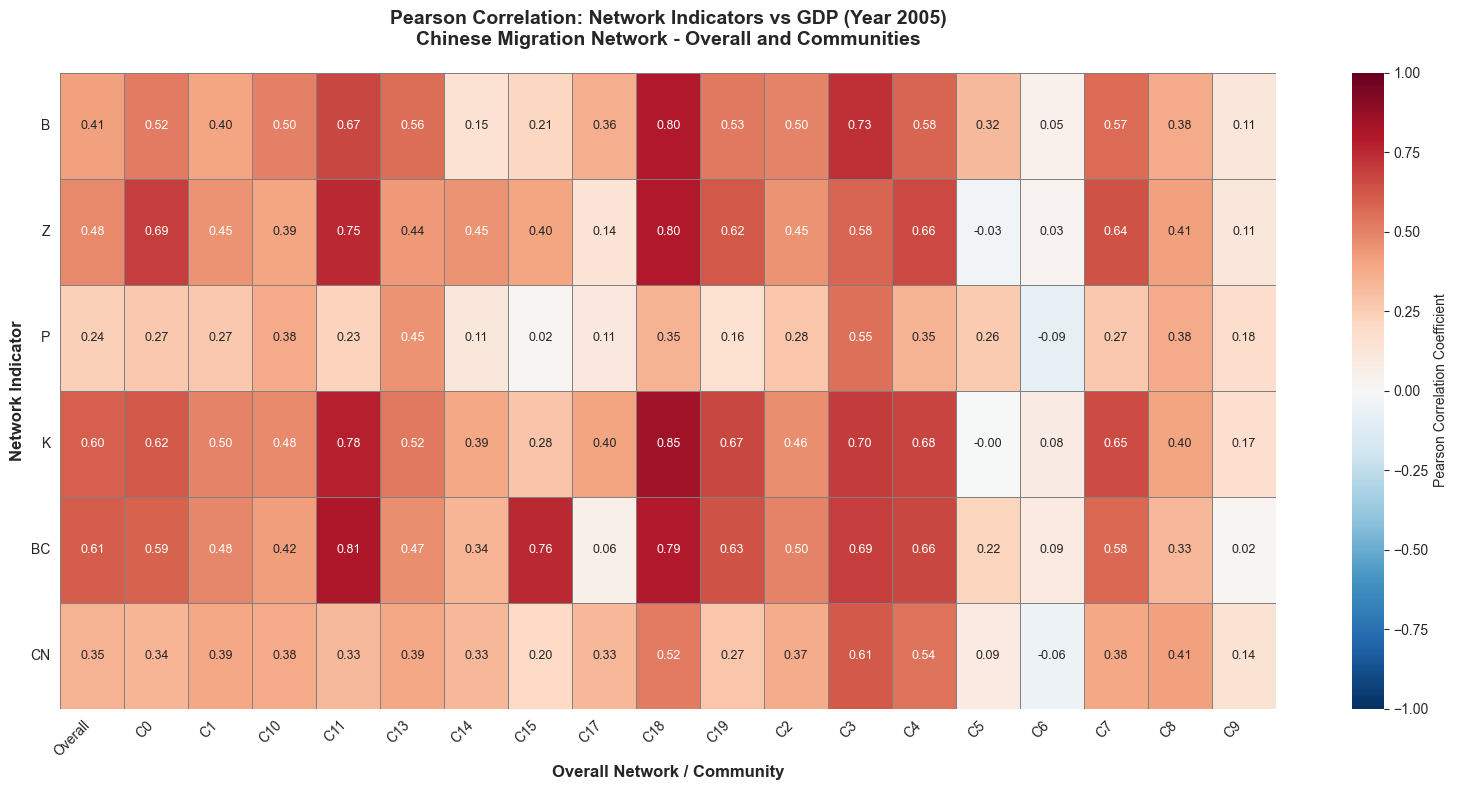

✓ Saved: correlation_heatmap_year_2005.png



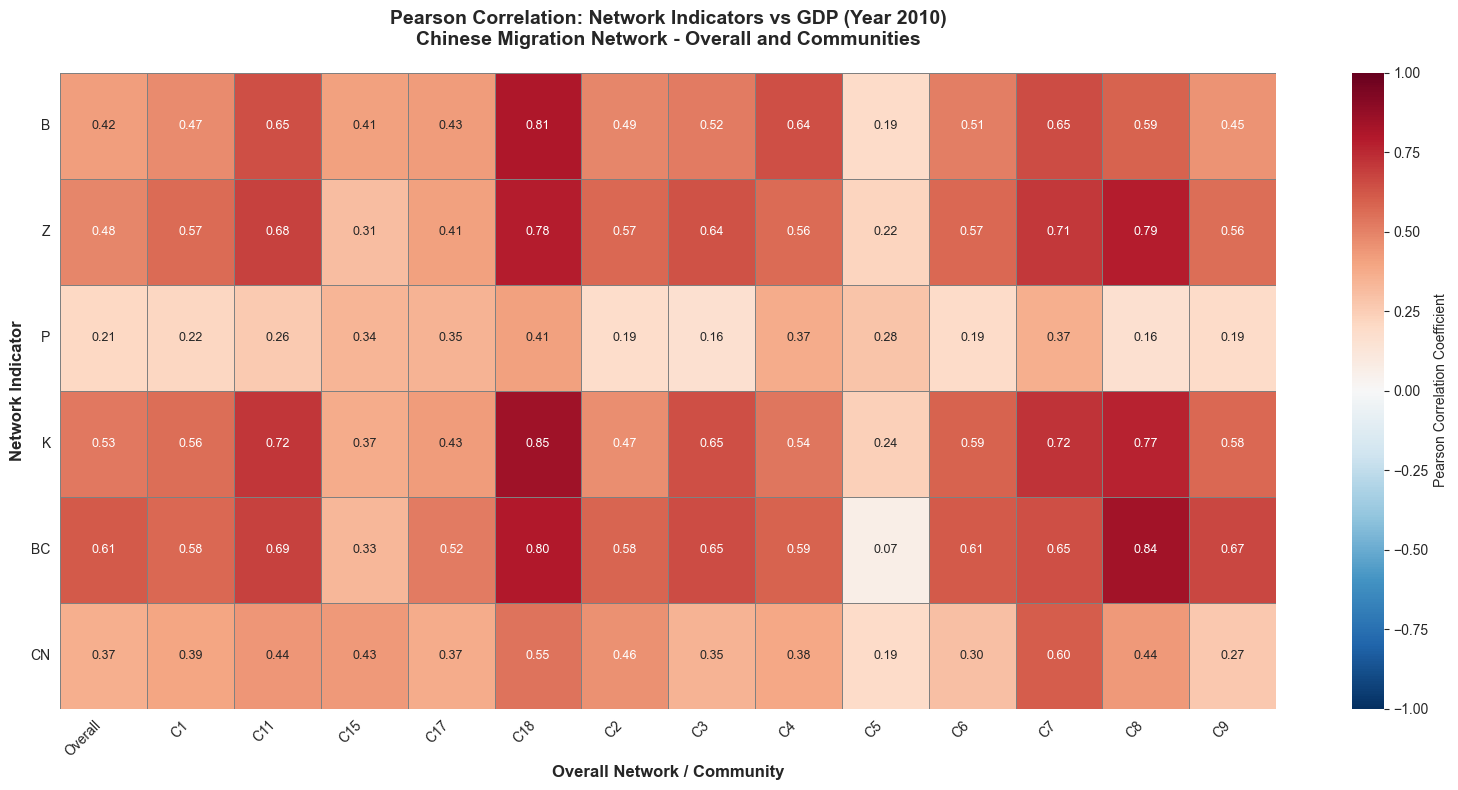

✓ Saved: correlation_heatmap_year_2010.png



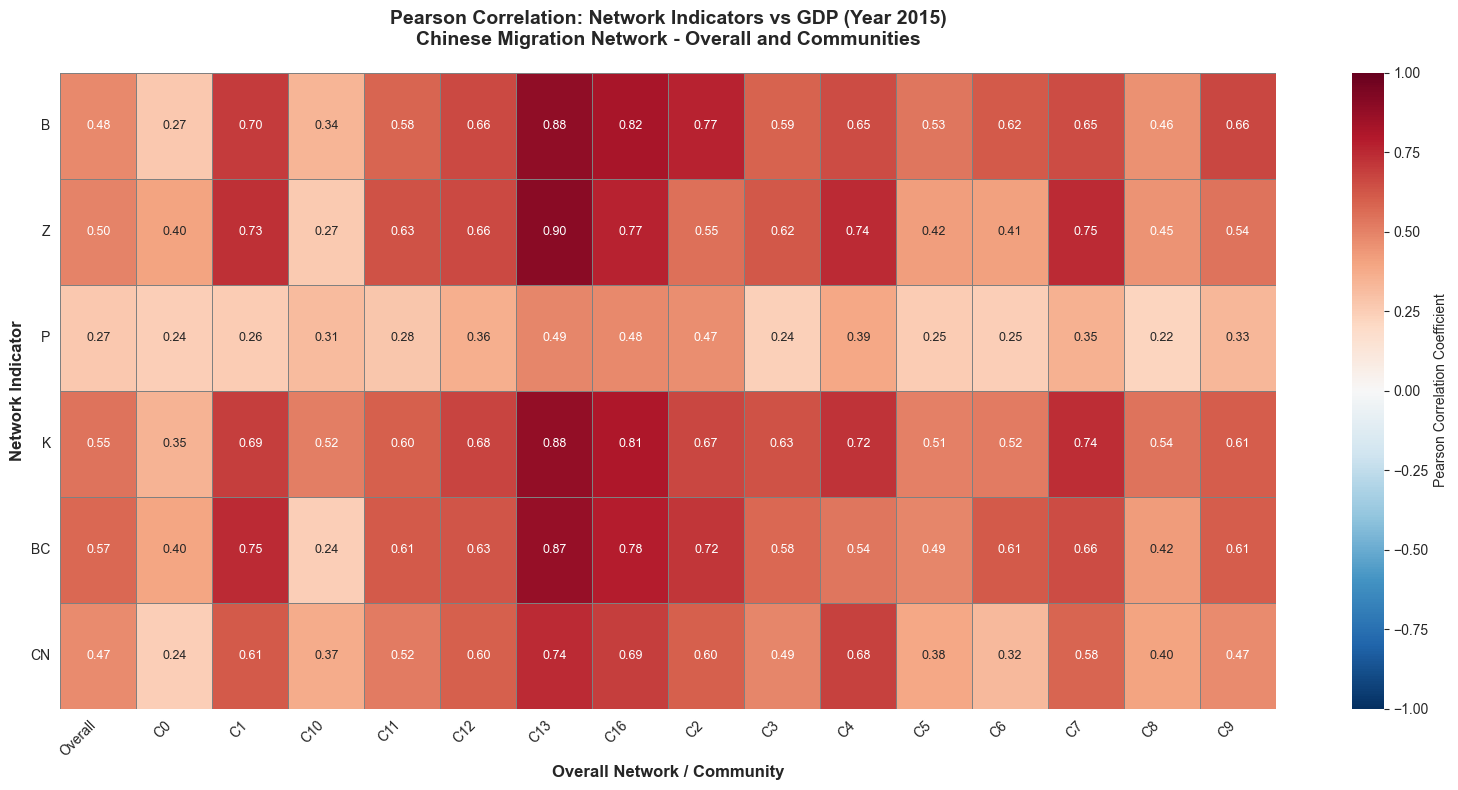

✓ Saved: correlation_heatmap_year_2015.png

✓ Heatmaps created for sample years


In [19]:
print("Creating correlation heatmaps for sample years...\n")

# Function to create heatmap for a specific year
def create_heatmap_for_year(df_yearly_corr, year, indicators=None):
    """Create correlation heatmap for a specific year"""
    if indicators is None:
        indicators = list(network_indicators.values())
    
    year_data = df_yearly_corr[df_yearly_corr['year'] == year].copy()
    
    if len(year_data) == 0:
        return None
    
    # Build data matrix
    communities_list = sorted([c for c in year_data['community'].unique() if c != 'Overall'])
    columns = ['Overall'] + communities_list
    
    heatmap_data = []
    for abbrev in indicators:
        row_data = []
        for comm in columns:
            comm_row = year_data[year_data['community'] == comm]
            if len(comm_row) > 0:
                corr = comm_row.iloc[0].get(f'{abbrev}_corr', np.nan)
                row_data.append(corr)
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
    
    return pd.DataFrame(heatmap_data, index=indicators, columns=columns)


# Create heatmaps for sample years
sample_years = [2005, 2010, 2015]

for year in sample_years:
    heatmap_df = create_heatmap_for_year(df_yearly_corr, year)
    
    if heatmap_df is not None:
        fig, ax = plt.subplots(figsize=(16, 8))
        
        sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1,
                    cbar_kws={'label': 'Pearson Correlation Coefficient'},
                    linewidths=0.5, linecolor='gray', ax=ax,
                    annot_kws={'size': 9})
        
        plt.title(f'Pearson Correlation: Network Indicators vs GDP (Year {year})\n' +
                  'Chinese Migration Network - Overall and Communities',
                  fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Overall Network / Community', fontsize=12, fontweight='bold')
        plt.ylabel('Network Indicator', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        filename = f'correlation_heatmap_year_{year}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Saved: {filename}\n")

print("✓ Heatmaps created for sample years")

## 10. Temporal Evolution of Correlations

Track how correlations change over time for the overall network and specific communities.

Creating temporal evolution plots...



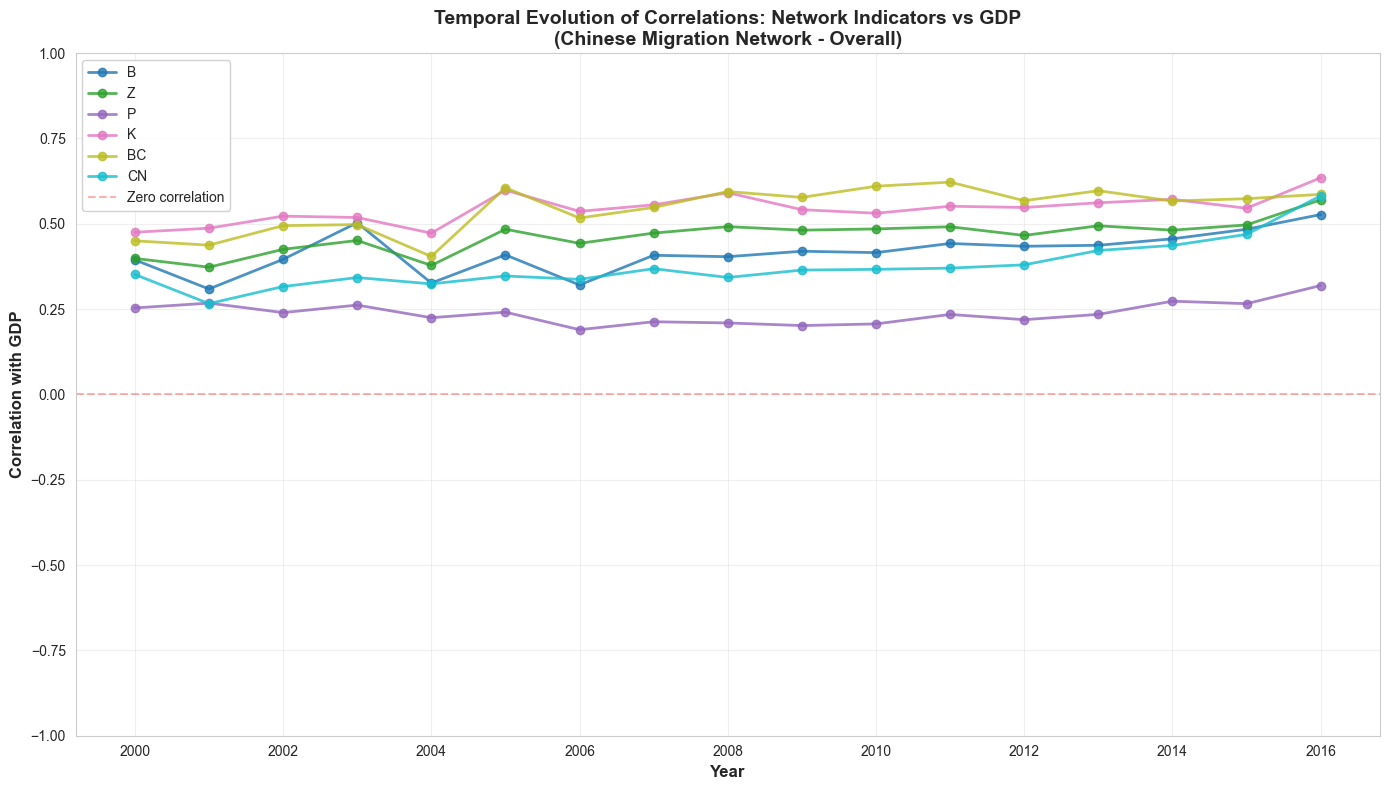

✓ Saved: correlation_temporal_evolution_overall.png

Temporal Evolution Summary (Overall Network):
B   : mean=0.417, std=0.060, min=0.309, max=0.527
Z   : mean=0.464, std=0.049, min=0.373, max=0.570
P   : mean=0.239, std=0.033, min=0.190, max=0.319
K   : mean=0.544, std=0.043, min=0.473, max=0.635
BC  : mean=0.544, std=0.066, min=0.404, max=0.622
CN  : mean=0.376, std=0.071, min=0.266, max=0.582

✓ Temporal evolution analysis complete


In [20]:
print("Creating temporal evolution plots...\n")

# Filter to Overall Network only
df_overall_temporal = df_yearly_corr[df_yearly_corr['community'] == 'Overall'].copy()
df_overall_temporal = df_overall_temporal.sort_values('year')

# Plot all indicators
fig, ax = plt.subplots(figsize=(14, 8))

indicators_to_plot = list(network_indicators.values())
colors = plt.cm.tab10(np.linspace(0, 1, len(indicators_to_plot)))

for idx, abbrev in enumerate(indicators_to_plot):
    col_name = f'{abbrev}_corr'
    if col_name in df_overall_temporal.columns:
        ax.plot(df_overall_temporal['year'], df_overall_temporal[col_name], 
               marker='o', linewidth=2, markersize=6, 
               color=colors[idx], label=abbrev, alpha=0.8)

ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Zero correlation')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Correlation with GDP', fontsize=12, fontweight='bold')
ax.set_title('Temporal Evolution of Correlations: Network Indicators vs GDP\n(Chinese Migration Network - Overall)', 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('correlation_temporal_evolution_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: correlation_temporal_evolution_overall.png\n")

# Summary statistics
print("Temporal Evolution Summary (Overall Network):")
print("="*80)
for abbrev in indicators_to_plot:
    col_name = f'{abbrev}_corr'
    if col_name in df_overall_temporal.columns:
        values = df_overall_temporal[col_name].dropna()
        print(f"{abbrev:4s}: mean={values.mean():.3f}, std={values.std():.3f}, " +
              f"min={values.min():.3f}, max={values.max():.3f}")

print("\n✓ Temporal evolution analysis complete")

## 11. Generate LaTeX Tables for Publication

Create publication-ready LaTeX tables showing:
- **Table 1**: Correlation coefficients for Overall Network across all years
- **Table 2**: Correlation coefficients with p-values in compact format
- **Table 3**: Summary statistics across all years

In [23]:
print("Generating LaTeX tables for publication...\n")

# Filter to Overall Network only
df_overall = df_yearly_corr[df_yearly_corr['community'] == 'Overall'].copy()
df_overall = df_overall.sort_values('year')

# Get list of years and indicators
years = sorted(df_overall['year'].unique())
indicators = list(network_indicators.values())

print(f"Years: {len(years)} ({min(years):.0f}-{max(years):.0f})")
print(f"Indicators: {len(indicators)} ({', '.join(indicators)})\n")

# ============================================================================
# TABLE 1: Correlation Coefficients with Significance Markers (Transposed)
# ============================================================================

print("Creating Table 1: Correlation Coefficients (Indicators × Years)...\n")

# Build data matrix
latex_data = []

for abbrev in indicators:
    row = [abbrev]  # Start with indicator abbreviation
    
    for year in years:
        year_row = df_overall[df_overall['year'] == year]
        if len(year_row) > 0:
            corr = year_row.iloc[0].get(f'{abbrev}_corr', np.nan)
            pval = year_row.iloc[0].get(f'{abbrev}_pval', np.nan)
            
            # Format with significance markers
            if not np.isnan(corr):
                if pval < 0.001:
                    cell_value = f"{corr:.3f}***"
                elif pval < 0.01:
                    cell_value = f"{corr:.3f}**"
                elif pval < 0.05:
                    cell_value = f"{corr:.3f}*"
                else:
                    cell_value = f"{corr:.3f}"
            else:
                cell_value = "--"
        else:
            cell_value = "--"
        
        row.append(cell_value)
    
    latex_data.append(row)

# Create DataFrame
columns = ['Indicator'] + [str(int(y)) for y in years]
df_latex = pd.DataFrame(latex_data, columns=columns)

# Generate LaTeX code
latex_code = []
latex_code.append("\\begin{table}[htbp]")
latex_code.append("\\centering")
latex_code.append("\\caption{Pearson Correlation Coefficients: Network Indicators vs GDP (Overall Network, 2000-2016)}")
latex_code.append("\\label{tab:correlation_yearly}")
latex_code.append("\\small")
latex_code.append("\\begin{tabular}{l" + "c" * len(years) + "}")
latex_code.append("\\hline\\hline")

# Header row
header = "Indicator & " + " & ".join([str(int(y)) for y in years]) + " \\\\"
latex_code.append(header)
latex_code.append("\\hline")

# Data rows
for idx, row in df_latex.iterrows():
    row_str = row['Indicator'] + " & " + " & ".join(row[1:].values) + " \\\\"
    latex_code.append(row_str)

latex_code.append("\\hline\\hline")
latex_code.append("\\end{tabular}")
latex_code.append("\\begin{tablenotes}")
latex_code.append("\\small")
latex_code.append("\\item Notes: *** $p < 0.001$, ** $p < 0.01$, * $p < 0.05$.")
latex_code.append("\\item Network indicators: B (gatewayness), Z (provincialness), P (connectorness), K (degree), BC (betweenness), CN (core number).")
latex_code.append("\\end{tablenotes}")
latex_code.append("\\end{table}")

latex_table1 = "\n".join(latex_code)

# Save to file
with open('correlation_table_latex_yearly.tex', 'w') as f:
    f.write(latex_table1)

print("✓ Table 1 saved: correlation_table_latex_yearly.tex")
print(f"  Format: Indicators (rows) × Years (columns)")
print(f"  Size: {len(indicators)} indicators × {len(years)} years\n")

# Display preview
print("Preview (first 10 lines):")
print("-" * 80)
for line in latex_code[:10]:
    print(line)
print("...")
print("-" * 80)

Generating LaTeX tables for publication...

Years: 17 (2000-2016)
Indicators: 6 (B, Z, P, K, BC, CN)

Creating Table 1: Correlation Coefficients (Indicators × Years)...

✓ Table 1 saved: correlation_table_latex_yearly.tex
  Format: Indicators (rows) × Years (columns)
  Size: 6 indicators × 17 years

Preview (first 10 lines):
--------------------------------------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Pearson Correlation Coefficients: Network Indicators vs GDP (Overall Network, 2000-2016)}
\label{tab:correlation_yearly}
\small
\begin{tabular}{lccccccccccccccccc}
\hline\hline
Indicator & 2000 & 2001 & 2002 & 2003 & 2004 & 2005 & 2006 & 2007 & 2008 & 2009 & 2010 & 2011 & 2012 & 2013 & 2014 & 2015 & 2016 \\
\hline
B & 0.394*** & 0.309*** & 0.396*** & 0.503*** & 0.326*** & 0.409*** & 0.321*** & 0.408*** & 0.404*** & 0.420*** & 0.415*** & 0.442*** & 0.434*** & 0.437*** & 0.456*** & 0.484*** & 0.527*** \\
...
----------------------------------------

In [24]:
# ============================================================================
# TABLE 2: Compact Format with Correlation and P-value Columns
# ============================================================================

print("\nCreating Table 2: Compact format with r and p-value columns...\n")

# Build compact table
latex_code2 = []
latex_code2.append("\\begin{table}[htbp]")
latex_code2.append("\\centering")
latex_code2.append("\\caption{Pearson Correlations: Network Indicators vs GDP by Year (Overall Network)}")
latex_code2.append("\\label{tab:correlation_compact}")
latex_code2.append("\\footnotesize")
latex_code2.append("\\begin{tabular}{lcccccc}")
latex_code2.append("\\hline\\hline")
latex_code2.append("Year & \\multicolumn{6}{c}{Correlation Coefficient (p-value)} \\\\")
latex_code2.append("\\cmidrule(lr){2-7}")
latex_code2.append(" & B & Z & P & K & BC & CN \\\\")
latex_code2.append("\\hline")

# Add data rows for each year
for year in years:
    year_row = df_overall[df_overall['year'] == year]
    if len(year_row) == 0:
        continue
    
    row_data = [str(int(year))]
    
    for abbrev in indicators:
        corr = year_row.iloc[0].get(f'{abbrev}_corr', np.nan)
        pval = year_row.iloc[0].get(f'{abbrev}_pval', np.nan)
        
        if not np.isnan(corr):
            # Format: r (p)
            if pval < 0.001:
                cell = f"{corr:.3f}***"
            elif pval < 0.01:
                cell = f"{corr:.3f}**"
            elif pval < 0.05:
                cell = f"{corr:.3f}*"
            else:
                cell = f"{corr:.3f}"
        else:
            cell = "--"
        
        row_data.append(cell)
    
    latex_code2.append(" & ".join(row_data) + " \\\\")

latex_code2.append("\\hline\\hline")
latex_code2.append("\\end{tabular}")
latex_code2.append("\\begin{tablenotes}")
latex_code2.append("\\small")
latex_code2.append("\\item Notes: Significance levels: *** $p < 0.001$, ** $p < 0.01$, * $p < 0.05$.")
latex_code2.append("\\item B: gatewayness; Z: provincialness; P: connectorness; K: degree; BC: betweenness centrality; CN: core number.")
latex_code2.append("\\end{tablenotes}")
latex_code2.append("\\end{table}")

latex_table2 = "\n".join(latex_code2)

# Save to file
with open('correlation_table_latex_compact.tex', 'w') as f:
    f.write(latex_table2)

print("✓ Table 2 saved: correlation_table_latex_compact.tex")
print(f"  Format: Years (rows) × Indicators (columns)")
print(f"  Size: {len(years)} years × {len(indicators)} indicators\n")

# Display preview
print("Preview (first 15 lines):")
print("-" * 80)
for line in latex_code2[:15]:
    print(line)
print("...")
print("-" * 80)


Creating Table 2: Compact format with r and p-value columns...

✓ Table 2 saved: correlation_table_latex_compact.tex
  Format: Years (rows) × Indicators (columns)
  Size: 17 years × 6 indicators

Preview (first 15 lines):
--------------------------------------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Pearson Correlations: Network Indicators vs GDP by Year (Overall Network)}
\label{tab:correlation_compact}
\footnotesize
\begin{tabular}{lcccccc}
\hline\hline
Year & \multicolumn{6}{c}{Correlation Coefficient (p-value)} \\
\cmidrule(lr){2-7}
 & B & Z & P & K & BC & CN \\
\hline
2000 & 0.394*** & 0.399*** & 0.253*** & 0.475*** & 0.450*** & 0.352*** \\
2001 & 0.309*** & 0.373*** & 0.268*** & 0.487*** & 0.437*** & 0.266*** \\
2002 & 0.396*** & 0.425*** & 0.240*** & 0.522*** & 0.495*** & 0.316*** \\
2003 & 0.503*** & 0.451*** & 0.262*** & 0.518*** & 0.498*** & 0.342*** \\
...
-----------------------------------------------------------------------------

In [25]:
# ============================================================================
# TABLE 3: Summary Statistics Across All Years
# ============================================================================

print("\nCreating Table 3: Summary statistics (mean, std, min, max)...\n")

# Calculate summary statistics for each indicator
summary_data = []

for abbrev in indicators:
    col_name = f'{abbrev}_corr'
    values = df_overall[col_name].dropna()
    
    summary_data.append({
        'Indicator': abbrev,
        'Mean': values.mean(),
        'Std': values.std(),
        'Min': values.min(),
        'Max': values.max(),
        'N': len(values)
    })

df_summary = pd.DataFrame(summary_data)

# Generate LaTeX code
latex_code3 = []
latex_code3.append("\\begin{table}[htbp]")
latex_code3.append("\\centering")
latex_code3.append("\\caption{Summary Statistics: Correlation Coefficients Across Years (2000-2016)}")
latex_code3.append("\\label{tab:correlation_summary}")
latex_code3.append("\\begin{tabular}{lccccr}")
latex_code3.append("\\hline\\hline")
latex_code3.append("Indicator & Mean & Std Dev & Min & Max & N \\\\")
latex_code3.append("\\hline")

for _, row in df_summary.iterrows():
    latex_row = f"{row['Indicator']} & {row['Mean']:.3f} & {row['Std']:.3f} & {row['Min']:.3f} & {row['Max']:.3f} & {int(row['N'])} \\\\"
    latex_code3.append(latex_row)

latex_code3.append("\\hline\\hline")
latex_code3.append("\\end{tabular}")
latex_code3.append("\\begin{tablenotes}")
latex_code3.append("\\small")
latex_code3.append("\\item Notes: Statistics computed across all available years (2000-2016).")
latex_code3.append("\\item All correlations calculated for Overall Network (all communities combined).")
latex_code3.append("\\end{tablenotes}")
latex_code3.append("\\end{table}")

latex_table3 = "\n".join(latex_code3)

# Save to file
with open('correlation_table_latex_summary.tex', 'w') as f:
    f.write(latex_table3)

print("✓ Table 3 saved: correlation_table_latex_summary.tex")
print(f"  Contains summary statistics for {len(indicators)} indicators\n")

# Display preview
print("Preview:")
print("-" * 80)
for line in latex_code3:
    print(line)
print("-" * 80)

# Display summary DataFrame
print("\nSummary Statistics DataFrame:")
display(df_summary)


Creating Table 3: Summary statistics (mean, std, min, max)...

✓ Table 3 saved: correlation_table_latex_summary.tex
  Contains summary statistics for 6 indicators

Preview:
--------------------------------------------------------------------------------
\begin{table}[htbp]
\centering
\caption{Summary Statistics: Correlation Coefficients Across Years (2000-2016)}
\label{tab:correlation_summary}
\begin{tabular}{lccccr}
\hline\hline
Indicator & Mean & Std Dev & Min & Max & N \\
\hline
B & 0.417 & 0.060 & 0.309 & 0.527 & 17 \\
Z & 0.464 & 0.049 & 0.373 & 0.570 & 17 \\
P & 0.239 & 0.033 & 0.190 & 0.319 & 17 \\
K & 0.544 & 0.043 & 0.473 & 0.635 & 17 \\
BC & 0.544 & 0.066 & 0.404 & 0.622 & 17 \\
CN & 0.376 & 0.071 & 0.266 & 0.582 & 17 \\
\hline\hline
\end{tabular}
\begin{tablenotes}
\small
\item Notes: Statistics computed across all available years (2000-2016).
\item All correlations calculated for Overall Network (all communities combined).
\end{tablenotes}
\end{table}
---------------------

,Indicator,Mean,Std,Min,Max,N
0,B,0.416757,0.059847,0.308924,0.527046,17
1,Z,0.463671,0.048979,0.372865,0.570190,17
2,P,0.238524,0.032508,0.189705,0.319113,17
3,K,0.543626,0.042674,0.472539,0.634873,17
4,BC,0.544068,0.065898,0.404294,0.622060,17
5,CN,0.375617,0.071032,0.266123,0.582083,17


In [26]:
# ============================================================================
# COMBINED LATEX DOCUMENT (All Tables)
# ============================================================================

print("\nCreating combined LaTeX document with all tables...\n")

combined_latex = []
combined_latex.append("% Pearson Correlation Analysis: Network Indicators vs GDP")
combined_latex.append("% Chinese Migration Network (2000-2016)")
combined_latex.append("% Generated automatically from correlation analysis")
combined_latex.append("")
combined_latex.append("% Required packages:")
combined_latex.append("% \\usepackage{booktabs}")
combined_latex.append("% \\usepackage{threeparttable}")
combined_latex.append("")
combined_latex.append("% ============================================================================")
combined_latex.append("% Table 1: Yearly Correlations (Indicators × Years)")
combined_latex.append("% ============================================================================")
combined_latex.append("")
combined_latex.append(latex_table1)
combined_latex.append("")
combined_latex.append("\\clearpage")
combined_latex.append("")
combined_latex.append("% ============================================================================")
combined_latex.append("% Table 2: Compact Format (Years × Indicators)")
combined_latex.append("% ============================================================================")
combined_latex.append("")
combined_latex.append(latex_table2)
combined_latex.append("")
combined_latex.append("\\clearpage")
combined_latex.append("")
combined_latex.append("% ============================================================================")
combined_latex.append("% Table 3: Summary Statistics")
combined_latex.append("% ============================================================================")
combined_latex.append("")
combined_latex.append(latex_table3)

combined_text = "\n".join(combined_latex)

# Save combined document
with open('correlation_tables_all_latex.tex', 'w') as f:
    f.write(combined_text)

print("✓ Combined document saved: correlation_tables_all_latex.tex")
print(f"  Contains all 3 tables in one file\n")

# Create a CSV file with all correlation data for reference
print("Creating supplementary CSV file with all correlation and p-value data...\n")

# Prepare data for CSV
csv_data = []
for year in years:
    year_row = df_overall[df_overall['year'] == year]
    if len(year_row) == 0:
        continue
    
    row_dict = {'Year': int(year)}
    
    for abbrev in indicators:
        corr = year_row.iloc[0].get(f'{abbrev}_corr', np.nan)
        pval = year_row.iloc[0].get(f'{abbrev}_pval', np.nan)
        n = year_row.iloc[0].get(f'{abbrev}_n', 0)
        
        row_dict[f'{abbrev}_r'] = corr
        row_dict[f'{abbrev}_p'] = pval
        row_dict[f'{abbrev}_n'] = n
    
    csv_data.append(row_dict)

df_csv = pd.DataFrame(csv_data)
df_csv.to_csv('correlation_data_all_years.csv', index=False)

print("✓ CSV data saved: correlation_data_all_years.csv")
print(f"  Contains r, p-value, and n for each indicator and year\n")

print("="*80)
print("LATEX TABLE GENERATION COMPLETE")
print("="*80)
print("\nGenerated files:")
print("  1. correlation_table_latex_yearly.tex    - Indicators × Years format")
print("  2. correlation_table_latex_compact.tex   - Years × Indicators format") 
print("  3. correlation_table_latex_summary.tex   - Summary statistics")
print("  4. correlation_tables_all_latex.tex      - Combined document (all tables)")
print("  5. correlation_data_all_years.csv        - Raw data (r, p, n)")
print("\n✅ All LaTeX tables ready for publication!")


Creating combined LaTeX document with all tables...

✓ Combined document saved: correlation_tables_all_latex.tex
  Contains all 3 tables in one file

Creating supplementary CSV file with all correlation and p-value data...

✓ CSV data saved: correlation_data_all_years.csv
  Contains r, p-value, and n for each indicator and year

LATEX TABLE GENERATION COMPLETE

Generated files:
  1. correlation_table_latex_yearly.tex    - Indicators × Years format
  2. correlation_table_latex_compact.tex   - Years × Indicators format
  3. correlation_table_latex_summary.tex   - Summary statistics
  4. correlation_tables_all_latex.tex      - Combined document (all tables)
  5. correlation_data_all_years.csv        - Raw data (r, p, n)

✅ All LaTeX tables ready for publication!


## Summary

### Analysis Context
This notebook analyzes the **Chinese Migration Network (1980-2016)** at the county level, examining correlations between network structural indicators and regional GDP.

**Important:** Communities are detected separately for each year using the Louvain algorithm (random seed = 8). Therefore, community labels (C1, C2, etc.) are **not consistent across years**. All correlations are calculated on a **year-by-year basis** to ensure meaningful results.

### Generated Files

**Main Correlation Data:**
1. `correlation_network_gdp_yearly_by_community.csv` - Complete year-by-year correlation data (long format)
2. `correlation_network_gdp_formatted_all_years.csv` - Formatted tables with significance markers for all years
3. `correlation_data_all_years.csv` - Raw correlation data (r, p-value, n) for all years

**LaTeX Tables (Publication-Ready):**
4. `correlation_table_latex_yearly.tex` - Indicators × Years format
5. `correlation_table_latex_compact.tex` - Years × Indicators format
6. `correlation_table_latex_summary.tex` - Summary statistics table
7. `correlation_tables_all_latex.tex` - Combined document with all tables

**Visualizations:**
8. `correlation_heatmap_year_2005.png` - Heatmap for year 2005
9. `correlation_heatmap_year_2010.png` - Heatmap for year 2010  
10. `correlation_heatmap_year_2015.png` - Heatmap for year 2015
11. `correlation_temporal_evolution_overall.png` - Time series showing how correlations evolve over time

### Network Indicators Analyzed

**Core Hub Metrics:**
- **B** (gatewayness): Z-score of outside-module degree
- **Z** (provincialness): Z-score of inside-module degree  
- **P** (connectorness): Participation coefficient

**Centrality Metrics:**
- **K** (degree): Node degree (weighted)
- **BC** (betweenness): Betweenness centrality
- **CC** (clustering): Clustering coefficient

**Rich-Club & Connectivity Metrics:**
- **AND** (average_neighbor_degree): Average degree of neighbors (rich-club proxy)
- **CN** (core_number): K-core decomposition value
- **LHC** (local_hub_connectivity): Local hub connectivity ratio

### Analysis Approach

- **Year-by-year correlations**: Each year analyzed separately
- **Overall network**: All communities combined for each year
- **Individual communities**: Each migration community detected in that year
- **Significance levels**: *** for p < 0.001, ** for p < 0.01, * for p < 0.05
- **Temporal coverage**: Years with GDP data available (typically 2000-2016)

In [ ]:
print("="*80)
print("CORRELATION ANALYSIS COMPLETE")
print("Chinese Migration Network (1980-2016)")
print("="*80)
print("\n✓ All tables and visualizations generated successfully")
print("\n📊 Analysis Approach: Year-by-Year Correlations")
print("   Communities change annually, so each year is analyzed separately")
print("\n📈 Network Indicators Analyzed:")
print("   Core Hub Metrics: B, Z, P")
print("   Centrality Metrics: K, BC, CC")
print("   Rich-Club Metrics: AND, CN, LHC")
print("\nOutput files:")
print("  CSV Data:")
print("    - correlation_network_gdp_yearly_by_community.csv")
print("    - correlation_network_gdp_formatted_all_years.csv")
print("    - correlation_data_all_years.csv")
print("  LaTeX Tables (Publication-Ready):")
print("    - correlation_table_latex_yearly.tex")
print("    - correlation_table_latex_compact.tex")
print("    - correlation_table_latex_summary.tex")
print("    - correlation_tables_all_latex.tex (combined)")
print("  Visualizations:")
print("    - correlation_heatmap_year_2005.png")
print("    - correlation_heatmap_year_2010.png")
print("    - correlation_heatmap_year_2015.png")
print("    - correlation_temporal_evolution_overall.png")
print("\n✓ Ready for analysis and publication!")